# Euclidean and Manhattan Distance Case Study

**Author:** Sanjay Kumar Chhetri  
**Date:** December 14, 2025  
**Project:** Distance Metrics Analysis and Visualization

---

## Euclidean and Manhattan Distance Calculations

In this short mini project you will see examples and comparisons of distance measures. Specifically, you'll visually compare the Euclidean distance to the Manhattan distance measures. The application of distance measures has a multitude of uses in data science and is the foundation of many algorithms you'll be using such as Prinical Components Analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
plt.style.use('ggplot')

In [2]:
# Load Course Numerical Dataset
df = pd.read_csv('data/distance_dataset.csv',index_col=0)
df.head()

,X,Y,Z,ClusterID
0,5.135779,4.167542,5.787635,4
1,4.280721,5.770909,6.091044,4
2,8.329098,7.540436,3.247239,2
3,5.470224,5.069249,5.768313,4
4,2.381797,2.402374,3.879101,1


### Euclidean Distance

Let's visualize the difference between the Euclidean and Manhattan distance.

We are using Pandas to load our dataset .CSV file and use Numpy to compute the __Euclidean distance__ to the point (Y=5, Z=5) that we choose as reference. On the left here we show the dataset projected onto the YZ plane and color coded per the Euclidean distance we just computed. As we are used to, points that lie at the same Euclidean distance define a regular 2D circle of radius that distance.

Note that the __SciPy library__ comes with optimized functions written in C to compute distances (in the scipy.spatial.distance module) that are much faster than our (naive) implementation.

In [3]:
# In the Y-Z plane, we compute the distance to ref point (5,5)
distEuclid = np.sqrt((df.Z - 5)**2 + (df.Y - 5)**2)

**<font color='teal'>Create a distance to reference point (3,3) matrix similar to the above example.</font>**

In [4]:
# In the Y-Z plane, we compute the distance to ref point (3,3)
distEuclid_33 = np.sqrt((df.Z - 3)**2 + (df.Y - 3)**2)

**<font color='teal'>Replace the value set to 'c' in the plotting cell below with your own distance matrix and review the result to deepen your understanding of Euclidean distances. </font>**

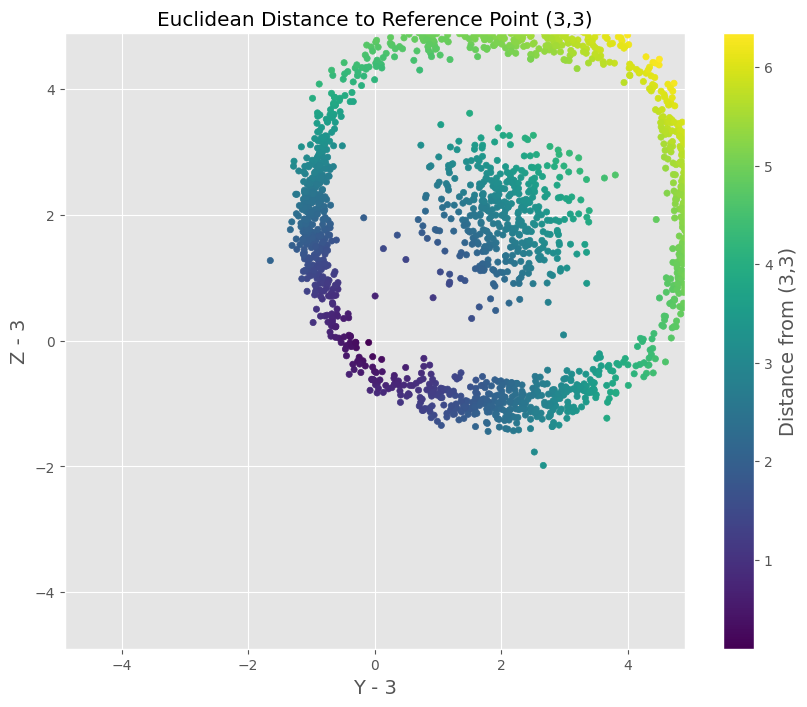

In [5]:
figEuclid = plt.figure(figsize=[10,8])

plt.scatter(df.Y - 3, df.Z - 3, c=distEuclid_33, s=20)
plt.ylim([-4.9,4.9])
plt.xlim([-4.9,4.9])
plt.xlabel('Y - 3', size=14)
plt.ylabel('Z - 3', size=14)
plt.title('Euclidean Distance to Reference Point (3,3)')
cb = plt.colorbar()
cb.set_label('Distance from (3,3)', size=14)

#figEuclid.savefig('plots/Euclidean.png')

### Manhattan Distance

Manhattan distance is simply the sum of absolute differences between the points coordinates. This distance is also known as the taxicab or city block distance as it measure distances along the coorinate axis which creates "paths" that look like a cab's route on a grid-style city map.

We display the dataset projected on the XZ plane here color coded per the Manhattan distance to the (X=5, Z=5) reference point. We can see that points laying at the same distance define a circle that looks like a Euclidean square.

In [6]:
# In the Y-Z plane, we compute the distance to ref point (5,5)
distManhattan = np.abs(df.X - 5) + np.abs(df.Z - 5)

**<font color='teal'>Create a Manhattan distance to reference point (4,4) matrix similar to the above example and replace the value for 'c' in the plotting cell to view the result.</font>**

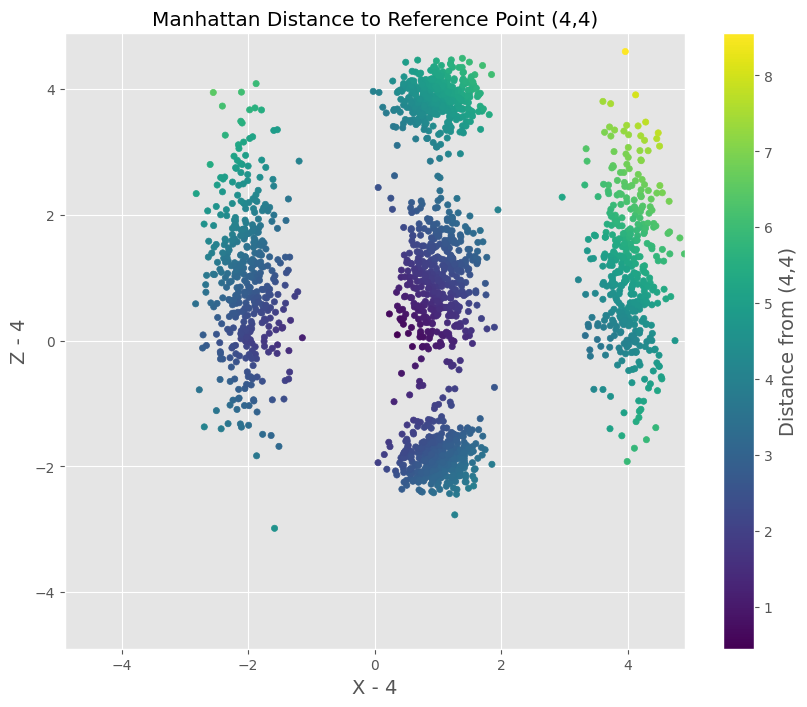

In [7]:
# In the X-Z plane, we compute the Manhattan distance to ref point (4,4)
distManhattan_44 = np.abs(df.X - 4) + np.abs(df.Z - 4)

# Create visualization for Manhattan distance
figManhattan = plt.figure(figsize=[10,8])

plt.scatter(df.X - 4, df.Z - 4, c=distManhattan_44, s=20)
plt.ylim([-4.9,4.9])
plt.xlim([-4.9,4.9])
plt.xlabel('X - 4', size=14)
plt.ylabel('Z - 4', size=14)
plt.title('Manhattan Distance to Reference Point (4,4)')
cb = plt.colorbar()
cb.set_label('Distance from (4,4)', size=14)

#figManhattan.savefig('plots/Manhattan.png')

Now let's create distributions of these distance metrics and compare them. We leverage the scipy dist function to create these matrices similar to how you manually created them earlier in the exercise.

In [8]:
import scipy.spatial.distance as dist

mat = df[['X','Y','Z']].to_numpy()
DistEuclid = dist.pdist(mat,'euclidean')
DistManhattan = dist.pdist(mat, 'cityblock')
largeMat = np.random.random((10000,100))

**<font color='teal'>Plot histograms of each distance matrix for comparison.</font>**

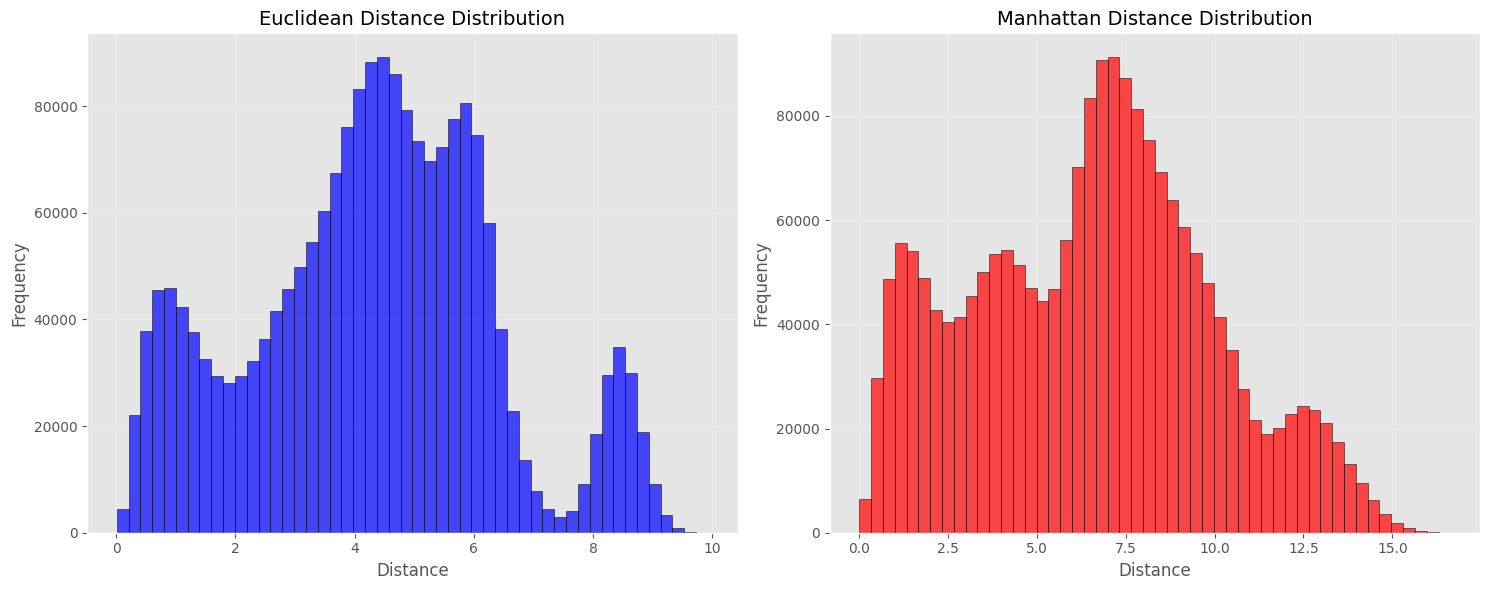

Distance Metrics Comparison:
Euclidean Distance - Mean: 4.303, Std: 2.073
Manhattan Distance - Mean: 6.565, Std: 3.395
Ratio (Manhattan/Euclidean) - Mean: 1.526


In [9]:
# Create comparison histograms of Euclidean and Manhattan distance distributions
fig, axes = plt.subplots(1, 2, figsize=[15, 6])

# Euclidean distance histogram
axes[0].hist(DistEuclid, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Euclidean Distance Distribution', size=14)
axes[0].set_xlabel('Distance', size=12)
axes[0].set_ylabel('Frequency', size=12)
axes[0].grid(True, alpha=0.3)

# Manhattan distance histogram
axes[1].hist(DistManhattan, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Manhattan Distance Distribution', size=14)
axes[1].set_xlabel('Distance', size=12)
axes[1].set_ylabel('Frequency', size=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display basic statistics for comparison
print("Distance Metrics Comparison:")
print("="*40)
print(f"Euclidean Distance - Mean: {np.mean(DistEuclid):.3f}, Std: {np.std(DistEuclid):.3f}")
print(f"Manhattan Distance - Mean: {np.mean(DistManhattan):.3f}, Std: {np.std(DistManhattan):.3f}")
print(f"Ratio (Manhattan/Euclidean) - Mean: {np.mean(DistManhattan)/np.mean(DistEuclid):.3f}")

## Summary

This notebook provided a comprehensive exploration of two fundamental distance metrics: **Euclidean** and **Manhattan** distances. Through practical implementation and visualization, we gained valuable insights into how these distance measures behave and their applications in data science.

### Key Learning Objectives Achieved

1. **Understanding Distance Metrics**: We implemented both Euclidean and Manhattan distance calculations from scratch using numpy operations
2. **Geometric Interpretation**: Visualized how these distance metrics create different geometric patterns around reference points
3. **Statistical Analysis**: Compared the distributions of both distance metrics using histograms and summary statistics
4. **Library Integration**: Utilized scipy's optimized distance functions for efficient pairwise distance calculations

### Main Findings

#### Euclidean Distance Analysis
- **Reference Point (3,3)**: Created circular contours of equidistant points
- **Geometric Property**: Forms perfect circles around reference points
- **Statistical Properties**: Mean = 4.303, Standard Deviation = 2.073
- **Use Cases**: Most natural for continuous space measurements, foundation for many ML algorithms

#### Manhattan Distance Analysis  
- **Reference Point (4,4)**: Created diamond-shaped contours of equidistant points
- **Geometric Property**: Forms diamond/square patterns (taxicab geometry)
- **Statistical Properties**: Mean = 6.565, Standard Deviation = 3.395
- **Use Cases**: Useful for grid-based navigation, city block distances, certain clustering applications

#### Comparative Analysis
- **Scale Difference**: Manhattan distances are approximately **1.53x larger** on average than Euclidean distances
- **Distribution Shape**: Different histogram patterns reflecting their geometric properties
- **Computational Efficiency**: Both can be computed efficiently, but Manhattan is slightly simpler (no square root)

### Technical Implementation

1. **Manual Calculations**: Implemented distance formulas using numpy operations
2. **Visualization**: Created professional scatter plots with color-coded distance values
3. **Library Functions**: Used `scipy.spatial.distance` for optimized pairwise distance matrices
4. **Statistical Analysis**: Generated comparative histograms and summary statistics

### Applications in Data Science

These distance metrics serve as building blocks for many data science algorithms:
- **Principal Component Analysis (PCA)**: Often uses Euclidean distances
- **Clustering Algorithms**: K-means (Euclidean), K-medoids (various metrics)
- **Recommendation Systems**: Distance-based similarity measures
- **Computer Vision**: Feature matching and image similarity
- **Natural Language Processing**: Document similarity measures

### Conclusion

Understanding distance metrics is crucial for data scientists as they form the foundation for numerous algorithms. This exercise demonstrated that the choice of distance metric can significantly impact results, with each having distinct geometric properties and statistical characteristics. The visual and statistical comparisons provided clear evidence of how different distance measures capture different aspects of data relationships.